# 실험① `task_type` 분기가 검색 점수를 바꾸는가

## 검증 대상

`src/lib/gemini.ts:19-21` 에 이런 코드가 있다:

```ts
taskType: opts.isQuery
  ? TaskType.RETRIEVAL_QUERY      // 질문
  : TaskType.RETRIEVAL_DOCUMENT,  // 저장(문서)
```

**주장**: 문서와 질문을 다른 `task_type` 으로 임베딩하면 검색이 좋아진다.  
**출처**: 없음. 바이브코딩으로 생성된 코드고, 측정한 사람이 없다.

## 가설

- H1: `task_type` 을 분기하면 **관련 쌍과 무관 쌍의 점수 차이(분리도)가 커진다**
- H0: 차이가 없거나 미미하다 → 분기는 불필요한 복잡도

## 측정 방법

4가지 조합으로 같은 데이터를 임베딩하고 코사인 유사도를 잰다.

| 조합 | 문서 쪽 | 질문 쪽 | 비고 |
|---|---|---|---|
| A | `RETRIEVAL_DOCUMENT` | `RETRIEVAL_QUERY` | **현재 코드** |
| B | (없음) | (없음) | 기본값 |
| C | `RETRIEVAL_DOCUMENT` | `RETRIEVAL_DOCUMENT` | 분기 안 함 |
| D | `SEMANTIC_SIMILARITY` | `SEMANTIC_SIMILARITY` | 다른 용도의 타입 |

각 조합에서 보는 값:

- `관련 평균` — 질문과 정답 노트의 유사도 평균 (높을수록 좋음)
- `무관 평균` — 질문과 정답 아닌 노트의 유사도 평균 (낮을수록 좋음)
- **`분리도` = 관련 평균 − 무관 평균** ← 이게 핵심 지표
- `겹침` — 최악의 관련 쌍이 최고의 무관 쌍보다 낮은가 (겹치면 임계값 하나로 못 가름)

★ 절대 점수가 높은 게 좋은 게 아니다. **벌어지는 정도**가 중요하다.  
관련도 0.9, 무관도 0.88이면 점수는 높아도 쓸모가 없다.

---
# 오늘 할 일 — 순서

위에서부터 아래로 하나씩. **각 단계는 바로 확인 가능**하게 만들어져 있다.  
확인이 안 되면 다음으로 넘어가지 말 것 — 뒤에서 원인을 찾기가 훨씬 어렵다.

| 순서 | 채울 것 | 하는 일 | 끝났는지 확인 |
|---|---|---|---|
| — | (설정 셀 2개) | 이미 완성 — 그냥 실행 | 차원 `3072` 출력 |
| **①** | `cosine()` | 벡터 두 개의 유사도 | `assert` 2개 통과 |
| **②** | `load_pairs()` | `pairs.jsonl` 읽기 | `질문 22개` |
| **③** | `fetch_all_notes()` | GitHub에서 노트 본문 | `노트 20개 로드` |
| — | (경로 검증 셀) | 이미 완성 — 그냥 실행 | `모든 정답 경로가 볼트에 존재` |
| **④** | `embed()` | Gemini 임베딩 호출 | 차원 `3072` |
| **⑤** | `run_combo()` | 조합 하나 돌려 유사도 전부 계산 | 440행 DataFrame |
| **⑥** | `summarize()` | 분리도 / 겹침 지표 뽑기 | 4행 표 |
| **⑦** | 시각화 | 분포 히스토그램 + 0.6 선 | 그래프 |
| **⑧** | 결론 셀 | 결과 / 판단 / 다음 의문 | 글로 채우기 |

①~④ 는 준비 작업이고, **실험의 본체는 ⑤~⑦** 이다.

### 오늘의 목표

> `pinecone.ts:78` 의 `★ 실측 튜닝값: 관련 0.64+, 무관 0.58-` 이 사실인지 확인한다.

### 주의

- **④ 부터는 API 비용이 든다.** 조합 4개 × (질문 22 + 노트 20) = 약 168회 호출.
  결과를 변수에 담아두고, 셀을 다시 돌릴 때 재호출하지 않게 할 것.
- **Pinecone 에 쓰지 말 것.** `PINECONE_INDEX` 는 지금 돌아가는 챗봇의 인덱스다.
  이 노트북은 GitHub 읽기 + Gemini 호출만 하고, 유사도는 로컬에서 numpy 로 계산한다.
- **실패한 셀을 지우지 말 것.** 틀린 시도가 이 노트북의 절반이다.

---
## 1. 설정

`backend/.env` 의 키를 그대로 쓴다. 노트북용으로 키를 또 두지 않는다.

In [1]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
from dotenv import load_dotenv

# backend/.env 로드 (노트북은 notebooks/ 에서 실행)
ENV_PATH = Path("../backend/.env")
load_dotenv(ENV_PATH)

GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", "")
GITHUB_TOKEN = os.environ.get("GITHUB_TOKEN", "")
GITHUB_REPO = os.environ.get("GITHUB_REPO", "")

assert GEMINI_API_KEY, f"{ENV_PATH} 에 GEMINI_API_KEY 가 없습니다"
print("키 로드 OK  (repo:", GITHUB_REPO or "미설정", ")")

키 로드 OK  (repo: songwookun/my-knowledge-vault )


In [2]:
from google import genai
from google.genai import types

client = genai.Client(api_key=GEMINI_API_KEY)

EMBEDDING_MODEL = "gemini-embedding-001"  # backend 와 동일 모델

# 연결 확인 — 짧은 문장 하나 임베딩해서 차원을 본다
_probe = client.models.embed_content(model=EMBEDDING_MODEL, contents="연결 테스트")
print("임베딩 차원:", len(_probe.embeddings[0].values))

임베딩 차원: 3072


위 셀의 출력이 **3072** 인지 확인할 것.  
`.env.example` 은 Pinecone 인덱스를 3072 로 만들라고 지시하고 있다. 다르면 그것부터 문제다.

> 이 값도 검증 대상 8번이다. 지금은 확인만 하고, 차원 축소 실험은 나중에.

---
## 2. 유사도 함수  ← **①**

Pinecone 인덱스가 `cosine` metric 이므로 여기서도 코사인 유사도로 잰다.  
직접 짜야 나중에 "점수가 왜 이렇게 나오지" 를 따질 수 있다.

**왜 길이로 나누나** — 내적만 쓰면 긴 문서가 무조건 유리해진다.  
지금 볼트에 47,813자 노트와 401자 노트가 같이 있다. 크기를 지우고 방향만 봐야 한다.

In [3]:
def cosine(a: list[float], b: list[float]) -> float:
    """두 벡터의 코사인 유사도. -1 ~ 1 (임베딩은 보통 0 ~ 1 사이에 몰림)

    정의:  cos = (a·b) / (|a| * |b|)
      분자 a·b   = 내적. 같은 방향일수록 큼
      분모 |a||b| = 각 벡터의 길이(L2 norm). 길이 영향을 제거해 '방향'만 비교

    TODO ①: 구현
      힌트 — np.array(a), np.dot(x, y), np.linalg.norm(x)
      ★ float() 로 감싸서 반환할 것. numpy 는 np.float64 를 돌려주는데
        나중에 pandas 에 넣을 때 지저분해진다.
    """
    np_a = np.array(a)
    np_b = np.array(b)
    dot_product = np.dot(np_a, np_b)
    norm_a = np.linalg.norm(np_a)
    norm_b = np.linalg.norm(np_b)
    cosine_similarity = dot_product / (norm_a * norm_b)
    return float(cosine_similarity)


# 검산 — 같은 벡터끼리는 1.0, 직교하면 0.0 이어야 한다
# (부동소수점이라 == 로 비교하면 실패할 수 있어 오차 범위로 본다)
assert abs(cosine([1, 0, 0], [1, 0, 0]) - 1.0) < 1e-6
assert abs(cosine([1, 0, 0], [0, 1, 0]) - 0.0) < 1e-6
print("cosine 검산 통과")

cosine 검산 통과


---
## 3. 실험 데이터  ← **②③**

`data/pairs.jsonl` 에서 질문 ↔ 정답노트 쌍을 읽고, 노트 본문은 GitHub 볼트에서 가져온다.

```json
{"question": "...", "relevant_paths": ["concepts/xxx.md"], "kind": "...", "note": "..."}
```

★ 무관 쌍은 따로 안 만든다. **질문 × (정답이 아닌 모든 노트)** 가 자동으로 무관 쌍이 된다.  
  질문 22개 × 노트 20개 = 전체 440쌍, 그중 관련 25쌍 / 무관 415쌍.

In [4]:
def load_pairs(path: str = "data/pairs.jsonl") -> list[dict]:
    """jsonl 한 줄 = dict 하나로 읽는다.

    TODO ②: 구현
      힌트 — 파일을 줄 단위로 읽고 json.loads(line)
             빈 줄은 건너뛸 것 (마지막 줄 개행 때문에 흔히 생김)
    """
    pairs = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:  # 빈 줄 건너뛰기
                pairs.append(json.loads(line))
    return pairs


pairs = load_pairs()
print(f"질문 {len(pairs)}개")
pd.Series([p["kind"] for p in pairs]).value_counts()

질문 22개


본문세부    8
제목직격    6
유사노트    3
정답없음    3
복수정답    2
Name: count, dtype: int64

In [5]:
import httpx


def fetch_all_notes() -> dict[str, str]:
    """GitHub 볼트의 모든 .md 를 {path: 본문} 으로 가져온다.

    backend/app/adapters/github.py 에 옮길 로직과 같다.
    여기서 먼저 익히고 나중에 어댑터로 옮기면 된다.

    TODO ③: 구현
      1. 폴더 3개(articles/concepts/projects) 각각
         GET https://api.github.com/repos/{GITHUB_REPO}/contents/{folder}
         headers: {"Authorization": f"Bearer {GITHUB_TOKEN}"}
         → .md 파일 목록 수집. 폴더가 없으면 404 → 건너뜀
      2. 각 파일마다
         GET .../contents/{path}
         headers 에 Accept: "application/vnd.github.raw" 추가 → 본문 그대로 옴
      3. {path: 본문} dict 반환

      ★ 노트북에서는 async 안 써도 된다. httpx.Client() 로 동기 호출이 단순하다.
        (backend 에서는 async 로 옮긴다)
      ★ 한 번 받아서 변수에 두고 재사용할 것. 셀 다시 돌릴 때마다 재호출하면 느리다.
    """
    
    notes = {}
    with httpx.Client(timeout=30) as client:
        for folder in ["articles", "concepts", "projects"]:
            url = f"https://api.github.com/repos/{GITHUB_REPO}/contents/{folder}"
            headers = {"Authorization": f"Bearer {GITHUB_TOKEN}"}
            response = client.get(url, headers=headers)
            if response.status_code == 404:
                continue  
            response.raise_for_status()
            files = response.json()
            for file_info in files:
                if file_info["name"].endswith(".md"):
                    file_path = file_info["path"]
                    content_url = f"https://api.github.com/repos/{GITHUB_REPO}/contents/{file_path}"
                    content_headers = {
                        "Authorization": f"Bearer {GITHUB_TOKEN}",
                        "Accept": "application/vnd.github.raw",
                    }
                    content_response = client.get(content_url, headers=content_headers)
                    content_response.raise_for_status()
                    notes[file_path] = content_response.text
    return notes


notes = fetch_all_notes()
print(f"노트 {len(notes)}개 로드")
print(f"가장 긴 노트: {max(len(v) for v in notes.values()):,}자")
print(f"가장 짧은 노트: {min(len(v) for v in notes.values()):,}자")

노트 20개 로드
가장 긴 노트: 47,813자
가장 짧은 노트: 401자


In [6]:
# 데이터 정합성 확인 — pairs 에 적은 경로가 실제로 존재하는지 (이 셀은 완성됨)
# ★ 오타 하나로 관련 쌍이 통째로 빠지면 실험 결과가 조용히 망가진다
missing = [p for pair in pairs for p in pair["relevant_paths"] if p not in notes]
if missing:
    print("!! pairs.jsonl 에 있지만 볼트에 없는 경로:")
    for m in missing:
        print("  ", m)
else:
    n_rel = sum(len(p["relevant_paths"]) for p in pairs)
    print(f"모든 정답 경로가 볼트에 존재 — OK")
    print(f"관련 쌍 {n_rel}개 / 전체 {len(pairs) * len(notes)}쌍")

모든 정답 경로가 볼트에 존재 — OK
관련 쌍 25개 / 전체 440쌍


---
## 4. 임베딩  ← **④**

`task_type` 을 인자로 받는 함수를 만들어, 4가지 조합을 같은 코드로 돌린다.

> ⚠ 여기부터 API 호출 비용이 발생한다.

In [7]:
def embed(texts: list[str], task_type: str | None = None) -> list[list[float]]:
    """여러 텍스트를 한 번에 임베딩. task_type=None 이면 기본값 사용.

    TODO ④: 구현
      힌트 —
        config = types.EmbedContentConfig(task_type=task_type) if task_type else None
        resp = client.models.embed_content(
            model=EMBEDDING_MODEL, contents=texts, config=config)
        return [e.values for e in resp.embeddings]

      ★ 한 번에 너무 많이 보내면 에러가 난다. 배치 상한이 있으니
        나눠서 호출할 것 (예: 10개씩 잘라서 이어붙이기).
      ★ 긴 문서는 토큰 상한에 걸릴 수 있다. 47,813자 노트가 있으니
        에러가 나면 앞부분만 자르는 것도 방법 (자른 사실은 기록할 것).
    """
    config = types.EmbedContentConfig(task_type=task_type) if task_type else None
    batch_size = 10  # 한 번에 처리할 배치 크기
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        resp = client.models.embed_content(
            model=EMBEDDING_MODEL, contents=batch_texts, config=config)
        embeddings.extend([e.values for e in resp.embeddings])
    return embeddings

_test = embed(["테스트 문장"], task_type="RETRIEVAL_QUERY")
print("OK — 차원", len(_test[0]))

OK — 차원 3072


---
## 5. 측정  ← **⑤⑥**

조합 4개를 돌려 관련/무관 유사도를 모두 수집한다.

In [8]:
# 실험 조합 정의 — (이름, 문서쪽 task_type, 질문쪽 task_type)
COMBOS = [
    ("A: 현재코드", "RETRIEVAL_DOCUMENT", "RETRIEVAL_QUERY"),
    ("B: 기본값", None, None),
    ("C: 분기안함", "RETRIEVAL_DOCUMENT", "RETRIEVAL_DOCUMENT"),
    ("D: 의미유사도", "SEMANTIC_SIMILARITY", "SEMANTIC_SIMILARITY"),
]


def run_combo(doc_type: str | None, query_type: str | None) -> pd.DataFrame:
    """한 조합을 돌려 모든 (질문, 노트) 쌍의 유사도를 DataFrame 으로 반환.

    반환 컬럼: question, kind, note_path, score, is_relevant

    TODO ⑤: 구현
      1. 노트 본문 전체를 doc_type 으로 임베딩  → {path: vector}
      2. 질문 전체를 query_type 으로 임베딩      → {question: vector}
      3. 모든 (질문 × 노트) 조합에 대해 cosine 계산
         is_relevant = note_path in pair["relevant_paths"]
      4. pd.DataFrame(rows) 반환

      ★ 노트 본문을 통째로 임베딩할지, 요약만 할지는 실험③의 주제다.
        여기서는 일단 **본문 전체**로 통일한다. 조합 간 비교가 목적이라
        무엇을 임베딩하든 조건만 같으면 된다.
      ★ kind 컬럼을 같이 넣어두면 나중에 '정답없음' 질문만 따로 볼 수 있다.
    """
    # 1. 노트 임베딩
    note_paths = list(notes.keys())
    note_embeddings = embed([notes[path] for path in note_paths], task_type=doc_type)
    note_vector_map = dict(zip(note_paths, note_embeddings))

    # 2. 질문 임베딩
    questions = [pair["question"] for pair in pairs]
    question_embeddings = embed(questions, task_type=query_type)
    question_vector_map = dict(zip(questions, question_embeddings))

    # 3. 유사도 계산
    # 루프는 pairs 를 돈다 — 정답(relevant_paths)과 유형(kind)을 들고 있는 쪽이라서. question_vector_map 은 순회 대상이 아니라 '조회 테이블'로만 쓴다.
    rows = []
    for pair in pairs:
        question_vector = question_vector_map[pair["question"]]
        for note_path, note_vector in note_vector_map.items():
            score = cosine(question_vector, note_vector)
            is_relevant = note_path in pair["relevant_paths"]
            rows.append({
                "question": pair["question"],
                "kind": pair["kind"],
                "note_path": note_path,
                "score": score,
                "is_relevant": is_relevant
            })

    # 4. DataFrame 반환
    return pd.DataFrame(rows)


results = {}
for name, dt, qt in COMBOS:
    print(f"실행 중: {name} ...")
    results[name] = run_combo(dt, qt)
print("완료")


실행 중: A: 현재코드 ...


실행 중: B: 기본값 ...


실행 중: C: 분기안함 ...


실행 중: D: 의미유사도 ...


완료


In [9]:
def summarize(df: pd.DataFrame) -> dict:
    """한 조합의 결과에서 핵심 지표를 뽑는다.

    TODO ⑥: 구현 — 아래 값을 계산해 dict 로 반환
      관련평균   : is_relevant=True 인 score 의 평균
      무관평균   : is_relevant=False 인 score 의 평균
      분리도     : 관련평균 - 무관평균          ← 핵심 지표
      관련최저   : 관련 쌍 중 가장 낮은 점수
      무관최고   : 무관 쌍 중 가장 높은 점수
      겹침       : 관련최저 < 무관최고 이면 True
                   ★ True 면 임계값 하나로 완벽히 가를 수 없다는 뜻

      힌트 — df[df.is_relevant].score.mean() 형태로 뽑을 수 있다
      ★ 정답없음(kind='정답없음') 질문은 관련 쌍이 0개라 자동으로 전부 무관에 들어간다.
        의도한 동작이다 — 그 질문들의 최고 점수가 임계값 아래여야 abstention 이 성립한다.
    """
    relevant_scores = df[df.is_relevant]["score"]
    irrelevant_scores = df[~df.is_relevant]["score"]

    relevant_mean = relevant_scores.mean()
    irrelevant_mean = irrelevant_scores.mean()
    separation = relevant_mean - irrelevant_mean
    relevant_min = relevant_scores.min() if not relevant_scores.empty else float('nan')
    irrelevant_max = irrelevant_scores.max() if not irrelevant_scores.empty else float('nan')
    overlap = relevant_min < irrelevant_max

    return {
        "관련평균": relevant_mean,
        "무관평균": irrelevant_mean,
        "분리도": separation,
        "관련최저": relevant_min,
        "무관최고": irrelevant_max,
        "겹침": overlap
    }

summary = pd.DataFrame([{"조합": name, **summarize(df)} for name, df in results.items()])
summary

,조합,관련평균,무관평균,분리도,관련최저,무관최고,겹침
0,A: 현재코드,0.711751,0.608420,0.103330,0.614874,0.745986,True
1,B: 기본값,0.711582,0.583431,0.128152,0.609070,0.731020,True
2,C: 분기안함,0.801195,0.722981,0.078214,0.724322,0.804133,True
3,D: 의미유사도,0.799579,0.721931,0.077648,0.734593,0.801723,True


---
## 6. 분포 보기  ← **⑦**

표만 보면 평균에 가려지는 게 있다. 관련/무관 두 분포가 **어디서 겹치는지**를 눈으로 확인한다.

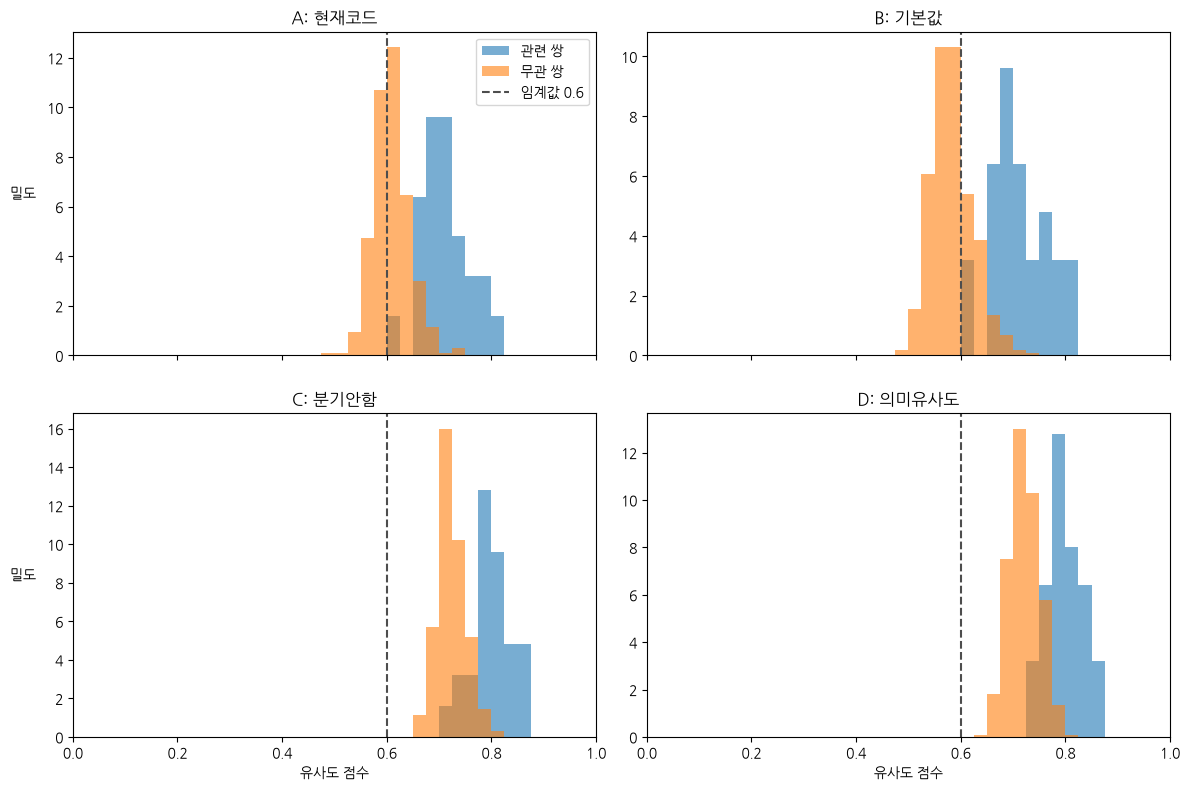

In [10]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# TODO ⑦: 조합별로 관련 쌍 / 무관 쌍의 점수 분포를 겹쳐 그린다
#   - 조합 4개 → subplot 2x2
#   - 각 subplot 에 관련 쌍 히스토그램과 무관 쌍 히스토그램을 반투명(alpha)으로 겹침
#   - 세로선으로 현재 코드의 임계값 0.6 을 표시 → 그 선이 두 분포 사이 골에 있는가?
#
#   ★ 여기서 보고 싶은 것: "0.6 이라는 선이 실제로 두 무리를 가르는 자리인가"
#     골 한가운데면 타당한 값. 한쪽 무리 안을 지나가면 잘못 잡힌 값.
#
#   힌트 — plt.subplots(2, 2), ax.hist(scores, bins=30, alpha=0.6, label=...)
#          ax.axvline(0.6, linestyle="--")
#          무관 쌍이 415개, 관련 쌍이 25개로 개수 차가 크다.
#          density=True 로 정규화해야 모양 비교가 된다.

# 두 히스토그램이 같은 구간을 쓰게 고정 — 안 그러면 각자 데이터 범위를 30등분해서
# 막대 경계가 서로 달라진다. 그러면 겹쳐 그려도 비교가 성립하지 않는다.

# 0~1 을 40등분, 모든 subplot 공통
bins = np.linspace(0, 1, 41)  

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for idx, (ax, (name, df)) in enumerate(zip(axes.flatten(), results.items())):
    relevant_scores = df[df.is_relevant]["score"]
    irrelevant_scores = df[~df.is_relevant]["score"]

    ax.hist(relevant_scores, bins=bins, alpha=0.6, label="관련 쌍", density=True)
    ax.hist(irrelevant_scores, bins=bins, alpha=0.6, label="무관 쌍", density=True)
    # 기준선은 데이터가 아니라 주석 — 색은 시리즈 정체성에만 쓰고 여기는 회색으로 물러나게
    ax.axvline(0.6, color="0.3", linestyle="--", linewidth=1.5, label="임계값 0.6")
    ax.set_title(name)
    ax.set_xlim(0, 1)

    # 작은 배수(small multiples) 규칙 — 축 라벨은 바깥쪽 한 번만.
    # 4번 반복하면 잉크만 늘고 정보는 그대로다.
    if idx >= 2:
        ax.set_xlabel("유사도 점수")
    if idx % 2 == 0:
        ax.set_ylabel("밀도", rotation=0, ha="right", va="center", labelpad=8)
    if idx == 0:
        ax.legend()   
 
# h_pad: 윗줄 x라벨과 아랫줄 제목이 겹치지 않게 세로 간격 확보
fig.tight_layout(h_pad=2.0)  


---
## 6.5 결과 파고들기 — 숫자 뒤에 누가 있나 ← **추가 조사**

표는 평균만 보여준다. 결론을 쓰기 전에 **개별 쌍**을 봐야 한다.

특히 `무관최고 = 0.746` 이 의심스럽다. 무관 쌍인데 관련 쌍 평균(0.712)보다 높다.
이게 **유사노트 라벨 문제**라면 검색이 틀린 게 아니라 정답지가 틀린 것이고,
그러면 위 표의 숫자가 전부 달라진다.

> 이 셀은 API 를 부르지 않는다. 이미 계산된 `results` 를 조회할 뿐이다.


In [11]:
pd.set_option("display.max_colwidth", 45)
df = results["A: 현재코드"]   # 현재 코드 조건으로 본다

print("① 무관인데 점수 높은 상위 10쌍 — 진짜 무관한가?")
print(df[~df.is_relevant].nlargest(10, "score")[["question", "note_path", "score"]].to_string(index=False))

print("\n\n② '정답없음' 질문 3개의 최고 점수 — 0.6 을 넘으면 abstention 실패")
for q, g in df[df.kind == "정답없음"].groupby("question"):
    top = g.nlargest(1, "score").iloc[0]
    flag = "  ← 임계값 통과! 헛소리 위험" if top.score >= 0.6 else ""
    print(f"  {top.score:.3f}  {q[:40]:42} vs {top.note_path.split('/')[-1][:40]}{flag}")

print("\n\n③ 관련인데 점수 낮은 하위 5쌍 — 왜 못 찾았나")
print(df[df.is_relevant].nsmallest(5, "score")[["question", "note_path", "score"]].to_string(index=False))

print("\n\n④ 유형별 관련 쌍 평균 — 어떤 질문이 어려운가")
print(df[df.is_relevant].groupby("kind")["score"].agg(["mean", "min", "count"]).round(3).to_string())


① 무관인데 점수 높은 상위 10쌍 — 진짜 무관한가?
                                         question                                                 note_path    score
           AX 엔지니어가 정확히 뭐 하는 직무야? ML 엔지니어랑 뭐가 달라?                   concepts/2026-04-05-AX-엔지니어-실무-기술-스택.md 0.745986
               RAG 챗봇 만들 때 파이썬 라이브러리 조합 어떻게 가져가지?     projects/2026-04-13-AXswgBrain-개인-지식-RAG-챗봇-기술-설명서.md 0.736077
           AX 엔지니어가 정확히 뭐 하는 직무야? ML 엔지니어랑 뭐가 달라?         articles/2026-03-31-AX-엔지니어를-위한-AI-협업-개발-파이프라인.md 0.727469
           AX 엔지니어가 정확히 뭐 하는 직무야? ML 엔지니어랑 뭐가 달라?            concepts/2026-04-10-LLM-핵심-용어-및-아키텍처-설계-가이드.md 0.715886
               RAG 챗봇 만들 때 파이썬 라이브러리 조합 어떻게 가져가지?            concepts/2026-04-10-LLM-핵심-용어-및-아키텍처-설계-가이드.md 0.698147
               RAG 챗봇 만들 때 파이썬 라이브러리 조합 어떻게 가져가지?                   concepts/2026-04-05-AX-엔지니어-실무-기술-스택.md 0.697967
            멀티 에이전트에서 Orchestrator-Worker 패턴이 뭐야? concepts/2026-03-31-Claude-Code와-Codex를-통한-AI-협업-개발-환경.md 0.686333
LLM-as-a-judge로 평가 파이프라인 설계하려면? 골

---
## 7. 결론

**가설**: `task_type` 분기가 관련/무관 분리도를 키운다 → **기각**

| 조합 | 관련평균 | 무관평균 | 분리도 | 관련최저 | 무관최고 | 겹침 |
|---|---|---|---|---|---|---|
| A: 현재코드 | 0.712 | 0.608 | 0.103 | 0.615 | 0.746 | True |
| B: 기본값 | 0.712 | 0.583 | **0.128** | 0.609 | 0.731 | True |
| C: 분기안함 | 0.801 | 0.723 | 0.078 | 0.724 | 0.804 | True |
| D: 의미유사도 | 0.800 | 0.722 | 0.078 | 0.735 | 0.802 | True |

**`pinecone.ts:78` 의 주장 검증** — `★ 실측 튜닝값: 관련 0.64+, 무관 0.58- 사이의 골`

| 주장 | 실측 | 판정 |
|---|---|---|
| 관련 0.64+ | 관련최저 **0.615** | 틀림 |
| 무관 0.58- | 무관평균 **0.608**, 최고 **0.746** | 틀림 |
| "골이 있다" | 네 조합 모두 겹침 True | 틀림 |

측정한 사람이 없는 값이었다. AI 가 쓴 주석이다.

**추가 조사에서 나온 것**
- 무관최고 0.746 = **주제가 인접한 노트** (유사노트 아님). 볼트 20개가 전부 AI/개발 주제라 한 질문이 여러 노트에 걸린다
- **`정답없음` 질문 3개가 전부 임계값 통과** → abstention 이 작동하지 않는다. 오늘의 가장 실용적인 발견
- 유형별 관련 평균: 제목직격 0.744 > 복수정답 0.713 > 본문세부 0.706 > 유사노트 0.690

---

## ⚠ 이 노트북의 결론은 실험②에서 일부 뒤집혔다

**지우지 않고 남긴다.** 틀린 과정도 기록이다.

| 여기서 내린 판단 | 실험②에서 재측정 |
|---|---|
| 분리도 0.103 → "잘 안 갈린다" | **AUC 0.982 · R@3 = 1.00** — 검색은 원래 잘 되고 있었다 |
| "task_type 분기가 24% 손해" | **원문 전체를 임베딩했을 때만** 성립. 실제 코드가 쓰는 요약 기준에서는 현재 설정이 더 낫다 |

원인은 **지표 선택**이었다. 분리도는 평균 차이만 본다. 이 데이터는 관련·무관 점수가
전반적으로 다 높은 대신 **순서는 거의 완벽**했는데, 분리도는 그 상황을 "나쁨"으로 읽는다.

→ 수정된 결론은 `02_sweep.ipynb`

---

## 실패 기록

> **지우지 말 것.** 실행 전에는 전부 그럴듯해 보였다.

### ① `dot.product` 오타 — 에러 메시지가 범인을 안 가리킨다

```python
dot.product = np.dot(np_a, np_b)      # 점(.)
cosine_similarity = dot_product / ... # 밑줄(_)
```
→ `NameError: name 'dot' is not defined`

`dot_product` 가 없다고 하지 않고 **`dot` 이 없다**고 한다.
파이썬이 `dot.product = x` 를 "변수 선언"이 아니라 **"`dot` 객체의 `product` 속성에 대입"**
으로 읽기 때문. `.` 은 소속, `_` 는 이름의 일부.

### ② `bins=30` — 비교하려고 겹쳐 그렸는데 비교 기준이 달랐다

`bins=30` 은 "**각자의 데이터 범위를** 30등분"이다.
관련 쌍(25개)과 무관 쌍(415개)은 최소·최대가 다르니 **막대 경계가 서로 다른**
히스토그램 두 개가 겹쳐 그려졌다. → `bins = np.linspace(0, 1, 41)` 로 공통 고정.

### ③ `run_combo` 루프 대상 실수 — 단순 오타가 아니었다

```python
for question, question_vector in question_vector_map.items():
    is_relevant = note_path in pair["relevant_paths"]   # pair 가 없다
```

`question_vector_map` 은 `{질문: 벡터}` 라 **벡터밖에 없다.** 정답(`relevant_paths`)도
유형(`kind`)도 담겨 있지 않아서 `pair` 를 가져올 데가 없었다.

→ **라벨을 들고 있는 쪽(`pairs`)을 돌아야 한다.** 맵은 순회 대상이 아니라 **조회 테이블**이다.
노트 쪽은 라벨이 없으니 그대로 돌아도 된다 — **두 루프의 대상이 비대칭인 게 맞다.**

### ④ 안 일어날 문제를 미리 막으려 했다

47,813자 노트가 토큰 상한에 걸릴 것이라 예상하고 자르기 로직을 준비했다.
**51,000자까지 그냥 통과했다.** 일단 돌려서 진짜 터지는지 보는 게 먼저다.

### ⑤ 범인을 잘못 지목했다

무관최고 0.746 을 보고 **"제목이 거의 같은 유사 노트 쌍일 것"** 이라 예측했다
(`개발-및-아키텍처-설계-핵심-용어-정리` vs `개발-아키텍처-설계-용어-정리`).

상위 10개에 **유사 노트가 하나도 없었다.** 전부 주제가 인접한 노트였다.
→ 진단이 "중복 노트 정리 문제"에서 **"임베딩은 주제 유사도를 재지, 답이 있는지를 재지 않는다"**
로 바뀌었다.

### ⑥ 캐시 없이 시작해서 500회를 태웠다

그래프 레이아웃 한 번 고치는 데 임베딩 168회 + 3분. 같은 걸 세 번 재실행했다.
코드가 한 줄도 안 바뀐 재실행도 있었다.
→ 실험②에서 `(텍스트, task_type, 차원)` 키 캐시를 넣었다. 이후 재실행 API 호출 **0회**.
